# Классическая сеть и сеть с арбитром

Базовый опыт сопоставляет две сети Петри для пяти философов. Для каждой
сети вычисляется дискретная траектория алгоритмом Гиллеспи и непрерывная
mass-action аппроксимация. Все исходные маркировки сохраняются в CSV.

In [1]:
using DrWatson
@quickactivate "PetriDiningLab"

ENV["GKSwstype"] = "100"
using CairoMakie
using CSV
using DataFrames
using Random

include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

## Параметры обязательного опыта

In [2]:
const PHILOSOPHERS = 5
const HORIZON = 50.0
const BASE_RATES = vcat(fill(2.4, PHILOSOPHERS),
                        fill(0.8, PHILOSOPHERS),
                        fill(1.1, PHILOSOPHERS))

mkpath(datadir())
mkpath(plotsdir())

"/workspace/labs/lab05/project/plots"

## Стохастические траектории

In [3]:
classic_net, classic_initial = build_classical_network(PHILOSOPHERS)
arbiter_net, arbiter_initial = build_arbiter_network(PHILOSOPHERS)

classic = simulate_stochastic(classic_net, classic_initial, HORIZON;
    rates=BASE_RATES, rng=MersenneTwister(20260501))
arbiter = simulate_stochastic(arbiter_net, arbiter_initial, HORIZON;
    rates=BASE_RATES, rng=MersenneTwister(20260502))

CSV.write(datadir("dining_classic.csv"), classic.trajectory)
CSV.write(datadir("dining_arbiter.csv"), arbiter.trajectory)
CSV.write(datadir("dining_classic_events.csv"), classic.events)
CSV.write(datadir("dining_arbiter_events.csv"), arbiter.events)

"/workspace/labs/lab05/project/data/dining_arbiter_events.csv"

## Детерминированная аппроксимация

In [4]:
classic_ode = simulate_ode(classic_net, classic_initial, HORIZON;
    rates=BASE_RATES, saveat=0.1)
arbiter_ode = simulate_ode(arbiter_net, arbiter_initial, HORIZON;
    rates=BASE_RATES, saveat=0.1)
CSV.write(datadir("dining_classic_ode.csv"), classic_ode)
CSV.write(datadir("dining_arbiter_ode.csv"), arbiter_ode)

"/workspace/labs/lab05/project/data/dining_arbiter_ode.csv"

## Диагностика взаимной блокировки

In [5]:
summary = DataFrame([
    event_summary(classic, HORIZON, "Классическая сеть"),
    event_summary(arbiter, HORIZON, "Сеть с арбитром"),
])
CSV.write(datadir("dining_summary.csv"), summary)

println("=== Стохастические сети Петри: N=$(PHILOSOPHERS), T=$(HORIZON) ===")
show(summary; allrows=true, allcols=true)
println()
println("Deadlock обнаружен (классическая сеть): $(classic.deadlock)")
println("Deadlock обнаружен (сеть с арбитром): $(arbiter.deadlock)")

=== Стохастические сети Петри: N=5, T=50.0 ===
2×7 DataFrame
 Row │ variant            deadlock  last_time  events  meals  fairness  horizon
     │ String             Bool      Float64    Int64   Int64  Float64   Float64
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Классическая сеть      true   0.446562       5      0  0.0          50.0
   2 │ Сеть с арбитром       false  50.0           76     24  0.859701     50.0
Deadlock обнаружен (классическая сеть): true
Deadlock обнаружен (сеть с арбитром): false


## Четыре группы позиций классической сети

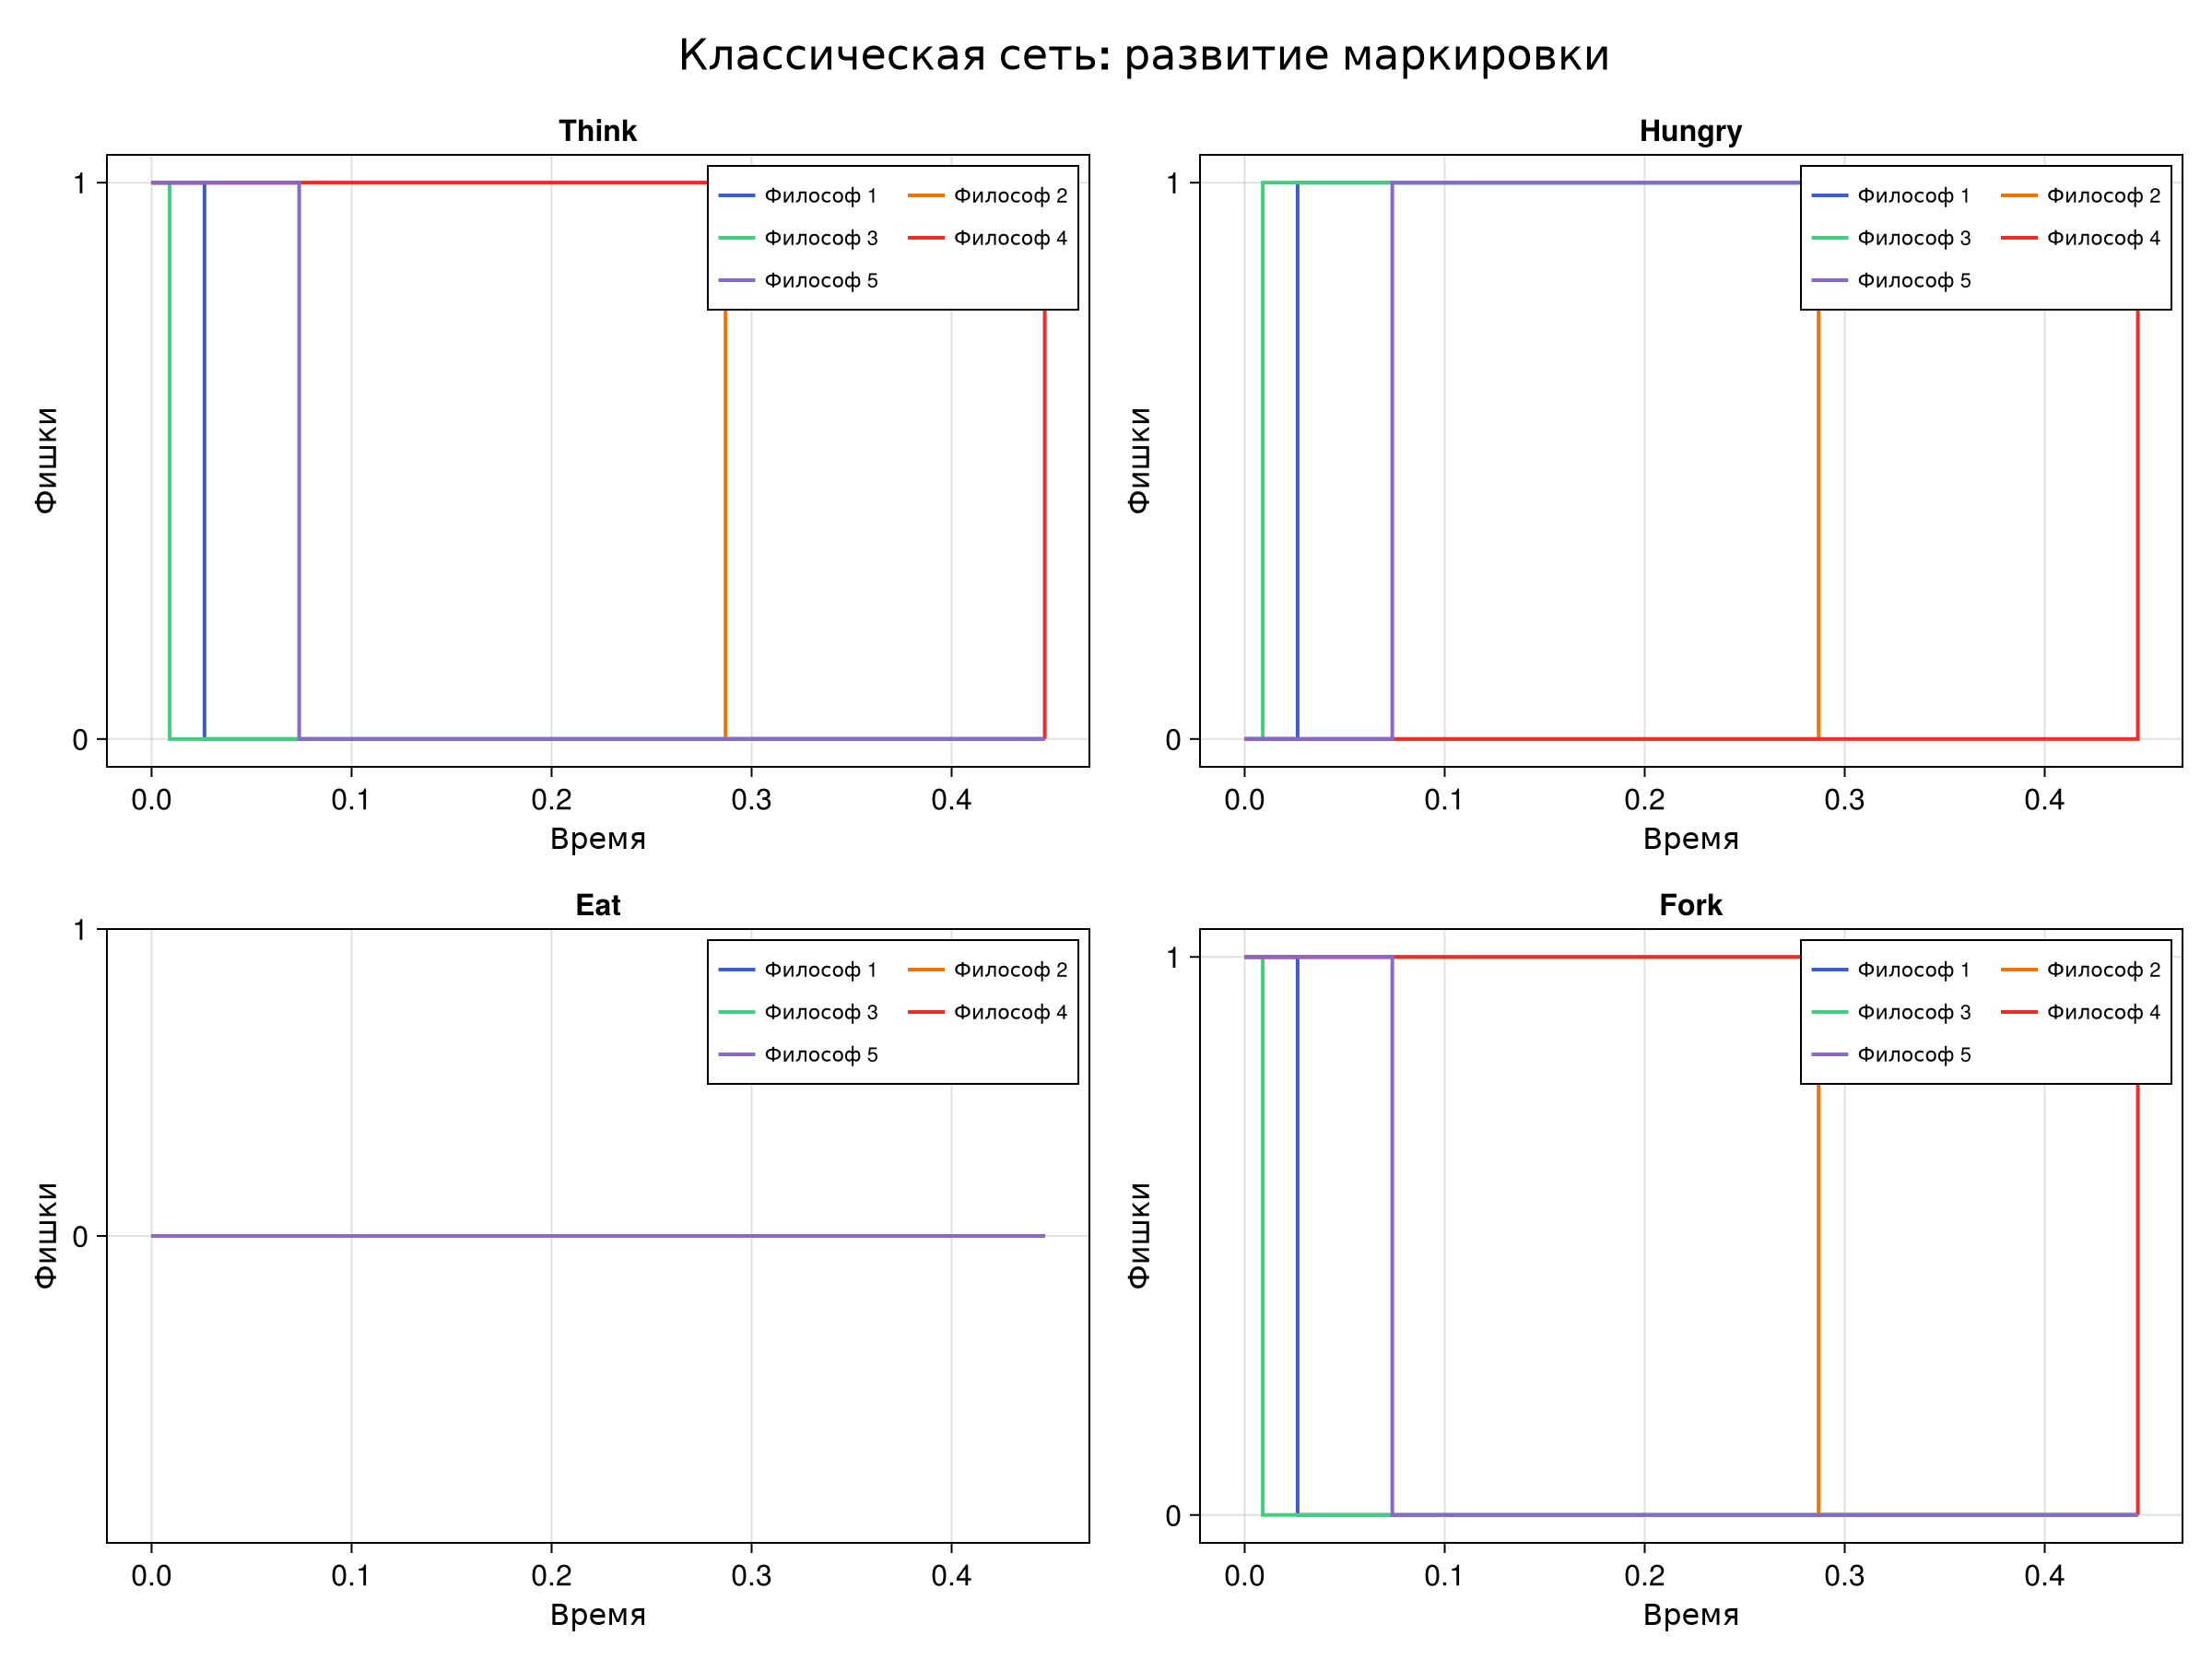

In [6]:
classic_figure = plot_marking_evolution(classic.trajectory, PHILOSOPHERS;
    title="Классическая сеть: развитие маркировки")
save(plotsdir("classic_simulation.png"), classic_figure, px_per_unit=1.5)
classic_figure

## Четыре группы позиций сети с арбитром

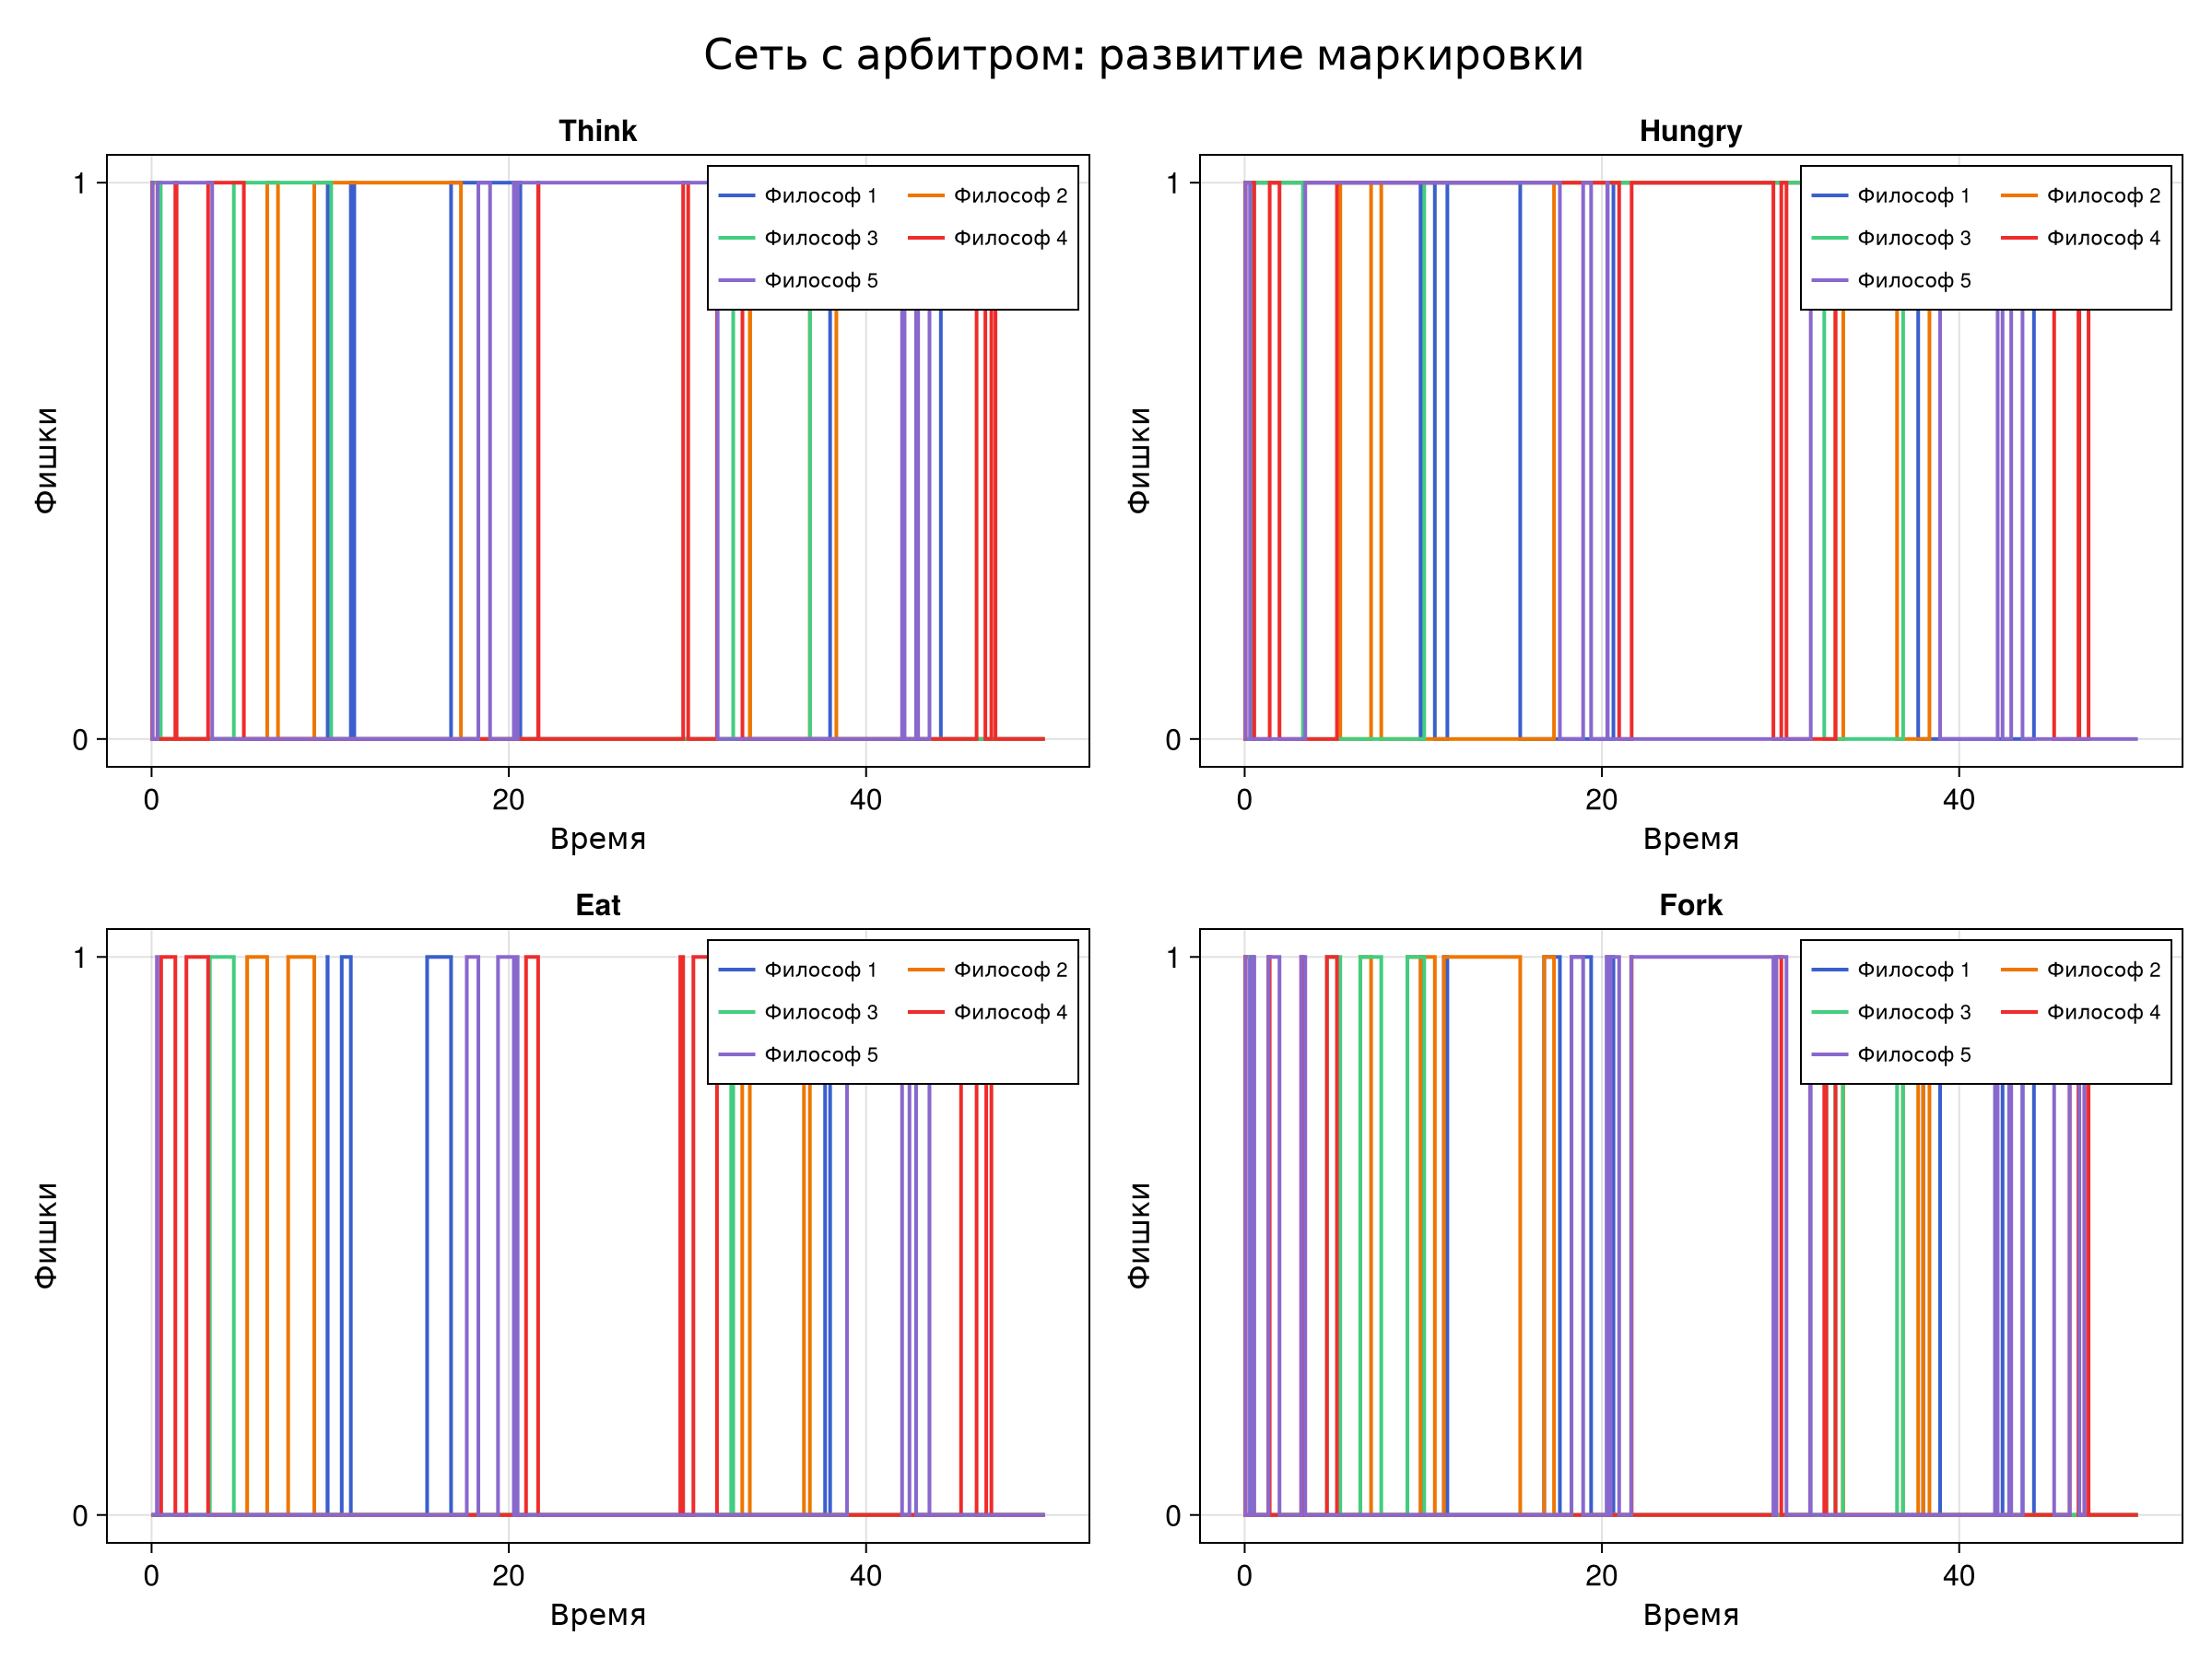

In [7]:
arbiter_figure = plot_marking_evolution(arbiter.trajectory, PHILOSOPHERS;
    title="Сеть с арбитром: развитие маркировки")
save(plotsdir("arbiter_simulation.png"), arbiter_figure, px_per_unit=1.5)
arbiter_figure

Классическая модель останавливается в маркировке без разрешённых переходов.
Ограничение арбитра оставляет один свободный ресурсный маршрут, поэтому
модифицированная сеть продолжает работу до заданного горизонта.